In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

In [2]:
df = pd.read_csv('aug_train.csv')

In [3]:
df.shape

(19158, 14)

In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [5]:
df.tail()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0
19157,23834,city_67,0.855,NaN,No relevent experience,no_enrollment,Primary School,NaN,2,NaN,NaN,1,127,0.0


In [6]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [7]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [8]:
df_clean = df.drop(columns=['enrollee_id', 'city'])

In [9]:
df_clean['experience'] = df_clean['experience'].replace({'>20': '21', '<1': '0'})
df_clean['experience'] = pd.to_numeric(df_clean['experience'], errors='coerce')
df_clean['experience'] = df_clean['experience'].fillna(df_clean['experience'].median())

In [10]:
df_clean['last_new_job'] = df_clean['last_new_job'].replace({'>4': '5', 'never': '0'})
df_clean['last_new_job'] = pd.to_numeric(df_clean['last_new_job'], errors='coerce')
df_clean['last_new_job'] = df_clean['last_new_job'].fillna(df_clean['last_new_job'].median())

In [11]:
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

In [12]:
# (One-Hot Encoding)
df_model = pd.get_dummies(df_clean, drop_first=True)

In [13]:
df_model.shape

(19158, 37)

Data Splitting & Scaling

In [14]:
X = df_model.drop(columns=['target'])
y = df_model['target']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model Training & Evaluation**

Logistic Regression

In [17]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("===Logistic Regression Performance Report===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

===Logistic Regression Performance Report===
              precision    recall  f1-score   support

         0.0       0.91      0.71      0.80      2877
         1.0       0.47      0.78      0.59       955

    accuracy                           0.73      3832
   macro avg       0.69      0.75      0.69      3832
weighted avg       0.80      0.73      0.75      3832

ROC-AUC Score: 0.7888141552336914


Random Forest Classifier

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("===Random Forest Performance Report===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

===Random Forest Performance Report===
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86      2877
         1.0       0.57      0.45      0.50       955

    accuracy                           0.78      3832
   macro avg       0.70      0.67      0.68      3832
weighted avg       0.76      0.78      0.77      3832

ROC-AUC Score: 0.7993943662228142


Model Comparison & Visuals

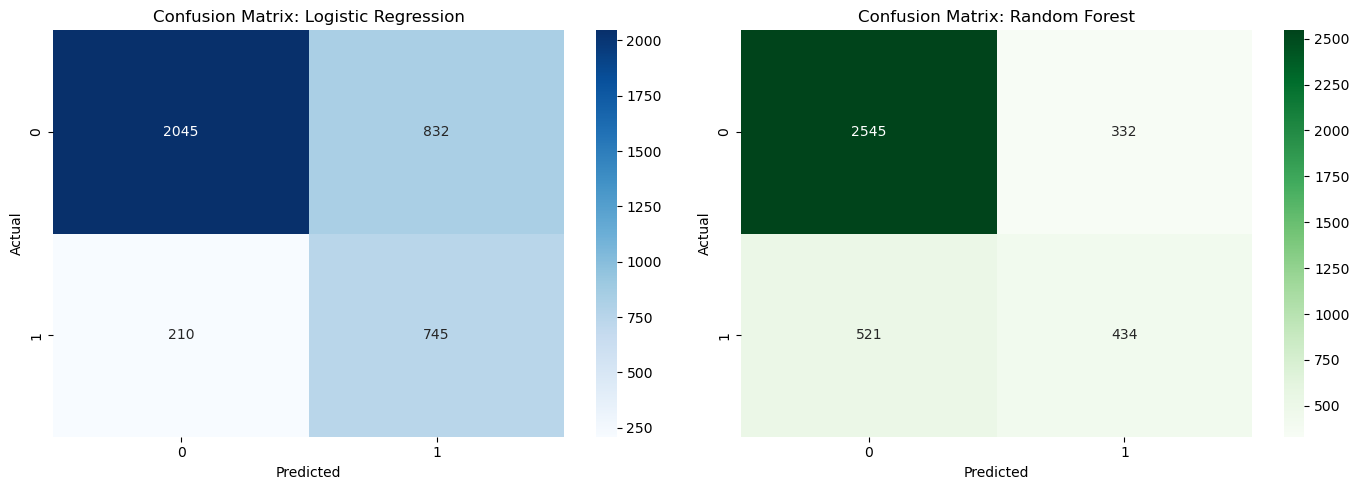

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Business Intelligence Insights

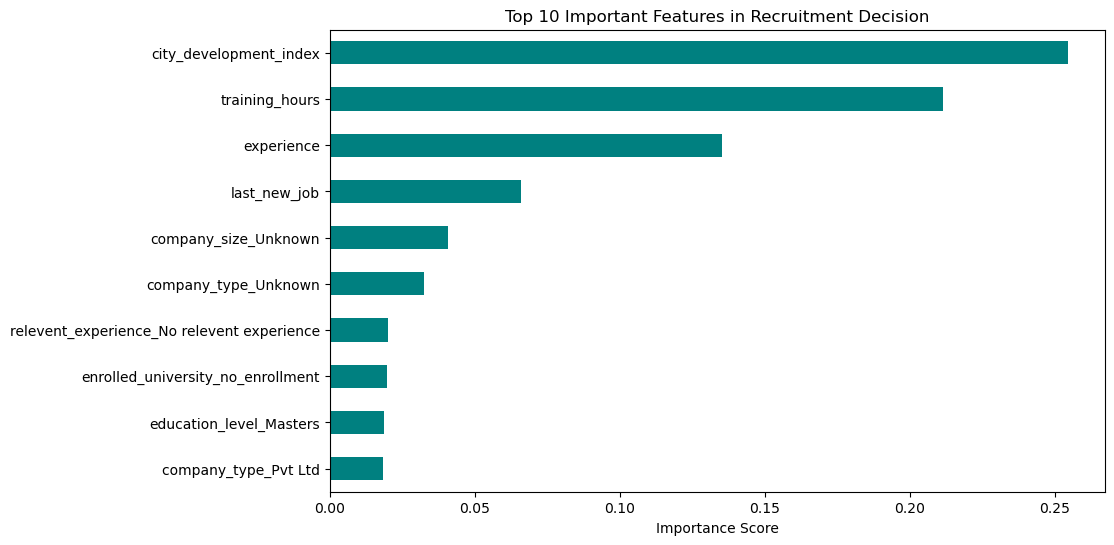

In [20]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Important Features in Recruitment Decision')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

Top 10 Applicant Recommendation System

In [21]:
# Preparing the comparison table and identifying the top candidates
ranking_df = X_test.copy()
ranking_df['Actual_Status'] = y_test.values
ranking_df['Suitability_Score_%'] = (y_prob_rf * 100).round(2)

top_10 = ranking_df.sort_values(by='Suitability_Score_%', ascending=False).head(10)

print("===List of the top 10 candidates advancing to the next stage===")
display(top_10[['experience', 'last_new_job', 'training_hours', 'Suitability_Score_%', 'Actual_Status']])

===List of the top 10 candidates advancing to the next stage===


,experience,last_new_job,training_hours,Suitability_Score_%,Actual_Status
5970,21.0,1.0,86,98.0,1.0
8808,3.0,1.0,9,97.0,1.0
10429,2.0,0.0,28,96.0,1.0
3371,21.0,5.0,6,94.0,1.0
9308,5.0,2.0,25,93.0,0.0
7046,3.0,0.0,62,93.0,1.0
4300,1.0,1.0,13,93.0,1.0
15083,21.0,2.0,23,92.0,0.0
9647,3.0,0.0,10,92.0,1.0
3952,2.0,1.0,62,92.0,1.0


In [22]:
import joblib

joblib.dump(rf_model, 'recruitment_model.pkl')
joblib.dump(list(X.columns), 'model_features.pkl')
print("Saved models successfully!")

Saved models successfully!


In [25]:
import joblib

loaded_model = joblib.load('recruitment_model.pkl')

joblib.dump(loaded_model, 'recruitment_model.pkl', compress=9)

print("تم ضغط النموذج بنجاح!")

تم ضغط النموذج بنجاح!
